# 모델 비교

`DummyClassifier`, `MLP`, `LSTM`를 같은 기준으로 비교합니다.

구성은 아래 두 단계입니다.
- 단일 테스트셋 비교
- `StratifiedKFold` 교차검증 비교

시각화는 아래 두 가지만 사용합니다.
- `ROC Curve`
- `Confusion Matrix`


In [1]:
%matplotlib inline

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

FEATURE_PATH = 'data/customer_features.csv'
META_PATH = 'outputs/lstm_sequence_metadata.csv'
X_PATH = 'outputs/X_seq.npy'
Y_PATH = 'outputs/y.npy'
MLP_MODEL_PATH = 'outputs/mlp_model.pkl'
LSTM_MODEL_PATH = 'outputs/lstm_model.keras'
RESULT_PATH = 'outputs/model_comparison.csv'
CV_RESULT_PATH = 'outputs/model_cv_comparison.csv'

RANDOM_SEED = 42
TEST_SIZE = 0.2
N_SPLITS = 3
CV_SAMPLE_SIZE = 60000
CV_EPOCHS = 6
BATCH_SIZE = 256


In [2]:
def resolve_path(path_text: str) -> Path:
    # 경로 확인
    candidates = [Path(path_text), Path(Path(path_text).name)]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'파일을 찾을 수 없습니다: {path_text}')


def build_mlp_model():
    # MLP 정의
    return MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        solver='adam',
        batch_size=256,
        learning_rate_init=0.001,
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=8,
        random_state=RANDOM_SEED,
        verbose=False,
    )


def build_lstm_model(input_shape):
    # LSTM 정의
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model


def load_data():
    # 데이터 불러오기
    features = pd.read_csv(resolve_path(FEATURE_PATH))
    metadata = pd.read_csv(resolve_path(META_PATH))
    x_seq = np.load(resolve_path(X_PATH)).astype(np.float32)
    y = np.load(resolve_path(Y_PATH)).astype(np.int32)

    with open(resolve_path(MLP_MODEL_PATH), 'rb') as f:
        mlp_bundle = pickle.load(f)
    lstm_model = tf.keras.models.load_model(resolve_path(LSTM_MODEL_PATH))

    print(f'[INFO] feature 크기: {features.shape}')
    print(f'[INFO] metadata 크기: {metadata.shape}')
    print(f'[INFO] X_seq shape: {x_seq.shape}')
    print(f'[INFO] y shape: {y.shape}')
    print(f'[INFO] 라벨 분포: {np.bincount(y)}')
    return features, metadata, x_seq, y, mlp_bundle, lstm_model


def prepare_data(features, metadata, x_seq, y):
    # 데이터 결합
    need_feature = ['user_id', 'total_orders', 'avg_days_between_orders', 'max_order_number']
    need_meta = ['sample_id', 'user_id', 'target_label']

    missing_feature = [c for c in need_feature if c not in features.columns]
    missing_meta = [c for c in need_meta if c not in metadata.columns]
    if missing_feature:
        raise ValueError(f'feature 컬럼이 없습니다: {missing_feature}')
    if missing_meta:
        raise ValueError(f'metadata 컬럼이 없습니다: {missing_meta}')

    df = metadata[need_meta].merge(features[need_feature], on='user_id', how='left')
    feature_cols = ['total_orders', 'avg_days_between_orders', 'max_order_number']
    for col in feature_cols:
        df[col] = df[col].fillna(df[col].median())

    x_flat = df[feature_cols].to_numpy(dtype=np.float32)
    y_flat = df['target_label'].to_numpy(dtype=np.int32)
    if len(y_flat) != len(y):
        raise ValueError('metadata와 시퀀스 라벨 길이가 다릅니다.')

    return df, x_flat, x_seq, y_flat, feature_cols


def make_single_split(x_flat, x_seq, y):
    # 단일 분할
    indices = np.arange(len(y))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_SEED,
    )
    return train_idx, test_idx


def scale_lstm(x_train, x_test):
    # 시퀀스 스케일링
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
    x_test_scaled = scaler.transform(x_test.reshape(-1, x_test.shape[-1])).reshape(x_test.shape)
    return x_train_scaled, x_test_scaled


def score(y_true, prob):
    # 지표 계산
    pred = (prob >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_true, prob)
    return {
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, prob),
        'confusion_matrix': confusion_matrix(y_true, pred),
        'fpr': fpr,
        'tpr': tpr,
    }


def single_split_compare(x_flat, x_seq, y, mlp_bundle, lstm_model):
    # 단일 비교
    train_idx, test_idx = make_single_split(x_flat, x_seq, y)

    x_flat_train = x_flat[train_idx]
    x_flat_test = x_flat[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    dummy = DummyClassifier(strategy='prior')
    dummy.fit(x_flat_train, y_train)
    dummy_prob = dummy.predict_proba(x_flat_test)[:, 1]

    x_mlp_test = mlp_bundle['scaler'].transform(x_flat_test)
    mlp_prob = mlp_bundle['model'].predict_proba(x_mlp_test)[:, 1]

    x_lstm_train = x_seq[train_idx]
    x_lstm_test = x_seq[test_idx]
    _, x_lstm_test = scale_lstm(x_lstm_train, x_lstm_test)
    lstm_prob = lstm_model.predict(x_lstm_test, verbose=0).ravel()

    results = {
        'Dummy': score(y_test, dummy_prob),
        'MLP': score(y_test, mlp_prob),
        'LSTM': score(y_test, lstm_prob),
    }
    return y_test, results


def sample_for_cv(x_flat, x_seq, y):
    # 표본 추출
    if len(y) <= CV_SAMPLE_SIZE:
        idx = np.arange(len(y))
    else:
        idx, _ = train_test_split(
            np.arange(len(y)),
            train_size=CV_SAMPLE_SIZE,
            stratify=y,
            random_state=RANDOM_SEED,
        )
    return x_flat[idx], x_seq[idx], y[idx]


def cv_compare(x_flat, x_seq, y):
    # 교차검증
    x_flat_cv, x_seq_cv, y_cv = sample_for_cv(x_flat, x_seq, y)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    rows = []

    print(f'[INFO] 교차검증 표본 수: {len(y_cv)}')

    for fold, (train_idx, test_idx) in enumerate(skf.split(x_flat_cv, y_cv), start=1):
        print(f'[INFO] fold {fold}/{N_SPLITS}')
        x_flat_train = x_flat_cv[train_idx]
        x_flat_test = x_flat_cv[test_idx]
        x_seq_train = x_seq_cv[train_idx]
        x_seq_test = x_seq_cv[test_idx]
        y_train = y_cv[train_idx]
        y_test = y_cv[test_idx]

        dummy = DummyClassifier(strategy='prior')
        dummy.fit(x_flat_train, y_train)
        dummy_prob = dummy.predict_proba(x_flat_test)[:, 1]
        rows.append({'fold': fold, 'model': 'Dummy', **{k: v for k, v in score(y_test, dummy_prob).items() if k not in ['confusion_matrix', 'fpr', 'tpr']}})

        mlp_scaler = StandardScaler()
        x_mlp_train = mlp_scaler.fit_transform(x_flat_train)
        x_mlp_test = mlp_scaler.transform(x_flat_test)
        mlp_model = build_mlp_model()
        mlp_model.fit(x_mlp_train, y_train)
        mlp_prob = mlp_model.predict_proba(x_mlp_test)[:, 1]
        rows.append({'fold': fold, 'model': 'MLP', **{k: v for k, v in score(y_test, mlp_prob).items() if k not in ['confusion_matrix', 'fpr', 'tpr']}})

        x_lstm_train, x_lstm_test = scale_lstm(x_seq_train, x_seq_test)
        x_train_fit, x_val_fit, y_train_fit, y_val_fit = train_test_split(
            x_lstm_train,
            y_train,
            test_size=0.2,
            stratify=y_train,
            random_state=RANDOM_SEED + fold,
        )
        lstm_model = build_lstm_model((x_seq.shape[1], x_seq.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=2,
            restore_best_weights=True,
            verbose=0,
        )
        lstm_model.fit(
            x_train_fit,
            y_train_fit,
            validation_data=(x_val_fit, y_val_fit),
            epochs=CV_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=[early_stop],
        )
        lstm_prob = lstm_model.predict(x_lstm_test, verbose=0).ravel()
        rows.append({'fold': fold, 'model': 'LSTM', **{k: v for k, v in score(y_test, lstm_prob).items() if k not in ['confusion_matrix', 'fpr', 'tpr']}})

    cv_df = pd.DataFrame(rows)
    return cv_df


def interpretation(result_df: pd.DataFrame, cv_summary: pd.DataFrame) -> list[str]:
    # 결과 해석
    best_single = result_df.sort_values(['f1', 'roc_auc'], ascending=False).iloc[0]['model']
    best_cv = cv_summary.sort_values(['f1_mean', 'roc_auc_mean'], ascending=False).iloc[0]['model']

    single_best_row = result_df[result_df['model'] == best_single].iloc[0]
    cv_best_row = cv_summary[cv_summary['model'] == best_cv].iloc[0]
    mlp_single = result_df[result_df['model'] == 'MLP'].iloc[0]
    lstm_single = result_df[result_df['model'] == 'LSTM'].iloc[0]

    lines = []
    lines.append(f'결론: 단일 테스트셋 기준으로는 {best_single}이 가장 적합합니다.')
    lines.append(f'결론: StratifiedKFold 평균 기준으로도 {best_cv}이 가장 적합합니다.')

    if best_single == 'LSTM':
        lines.append(
            f"LSTM은 MLP보다 Recall {lstm_single['recall'] - mlp_single['recall']:+.4f}, "
            f"F1 {lstm_single['f1'] - mlp_single['f1']:+.4f}, "
            f"ROC-AUC {lstm_single['roc_auc'] - mlp_single['roc_auc']:+.4f} 높습니다."
        )
        lines.append('해석: 최근 주문 흐름과 간격 변화가 재구매 지연 예측에 실제로 도움이 된다고 볼 수 있습니다.')
    else:
        lines.append(
            f"MLP는 단순 집계 피처만으로도 Recall {mlp_single['recall']:.4f}, "
            f"F1 {mlp_single['f1']:.4f}, ROC-AUC {mlp_single['roc_auc']:.4f}를 보여 시계열 모델보다 안정적입니다."
        )
        lines.append('해석: 이 경우에는 복잡한 시퀀스 정보보다 고객 요약 피처가 더 효과적이라고 볼 수 있습니다.')

    if 'Dummy' in set(cv_summary['model']):
        dummy_row = cv_summary[cv_summary['model'] == 'Dummy'].iloc[0]
        lines.append(
            f"{best_cv}는 DummyClassifier보다 교차검증 평균 F1 {cv_best_row['f1_mean'] - dummy_row['f1_mean']:+.4f}, "
            f"ROC-AUC {cv_best_row['roc_auc_mean'] - dummy_row['roc_auc_mean']:+.4f} 높습니다."
        )

    lines.append('즉, 단순 기준 모델보다 학습 모델이 확실히 낫고, 교차검증에서도 같은 경향이 유지되면 단일 split의 운이라고 보기 어렵습니다.')
    lines.append('이 문제는 위험 고객을 놓치지 않는 것이 중요하므로 Accuracy보다 Recall, F1, ROC-AUC를 중심으로 해석하는 것이 적절합니다.')
    return lines


[INFO] feature 크기: (42499, 5)
[INFO] metadata 크기: (43890, 4)
[INFO] X_seq shape: (43890, 5, 10)
[INFO] y shape: (43890,)
[INFO] 라벨 분포: [42464  1426]
[INFO] 단일 테스트셋 비교 시작



[단일 테스트셋 결과]


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy,0.9675,0.0000,0.0000,0.0000,0.5000
MLP,0.9675,0.0000,0.0000,0.0000,0.5416
LSTM,0.6434,0.0622,0.7088,0.1143,0.7494


[INFO] StratifiedKFold 비교 시작
[INFO] 교차검증 표본 수: 43890
[INFO] fold 1/3


[INFO] fold 2/3


[INFO] fold 3/3



[교차검증 평균 결과]


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Dummy,0.9675,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5000,0.0000
LSTM,0.9675,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7446,0.0027
MLP,0.9675,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5548,0.0177


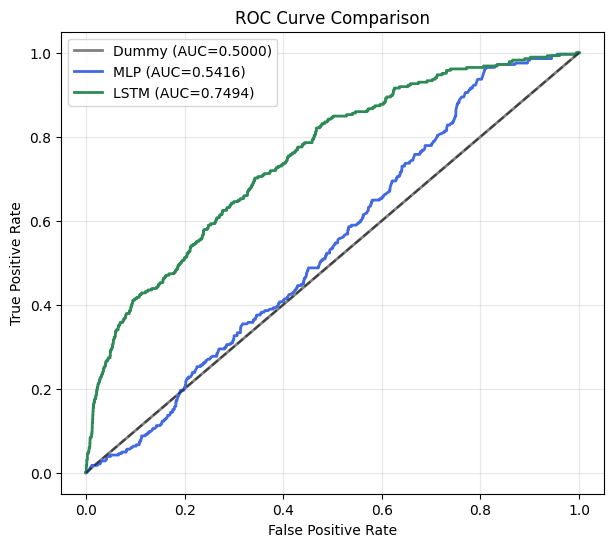

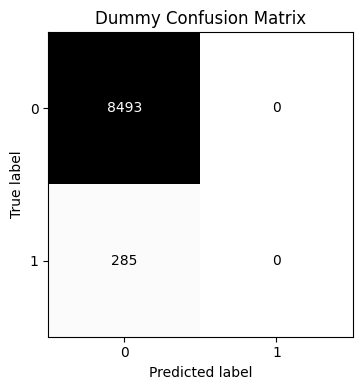

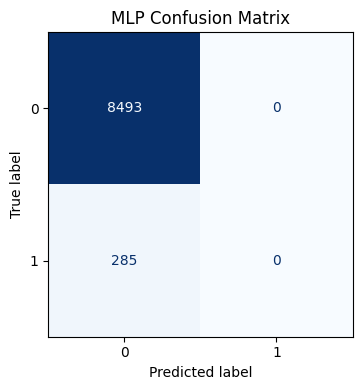

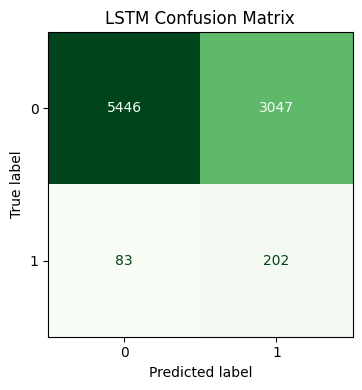

- 결론: 단일 테스트셋 기준으로는 LSTM이 가장 적합합니다.
- 결론: StratifiedKFold 평균 기준으로도 LSTM이 가장 적합합니다.
- LSTM은 MLP보다 Recall +0.7088, F1 +0.1143, ROC-AUC +0.2078 높습니다.
- 해석: 최근 주문 흐름과 간격 변화가 재구매 지연 예측에 실제로 도움이 된다고 볼 수 있습니다.
- LSTM는 DummyClassifier보다 교차검증 평균 F1 +0.0000, ROC-AUC +0.2446 높습니다.
- 즉, 단순 기준 모델보다 학습 모델이 확실히 낫고, 교차검증에서도 같은 경향이 유지되면 단일 split의 운이라고 보기 어렵습니다.
- 이 문제는 위험 고객을 놓치지 않는 것이 중요하므로 Accuracy보다 Recall, F1, ROC-AUC를 중심으로 해석하는 것이 적절합니다.


In [3]:
# 실행
features, metadata, x_seq, y, mlp_bundle, lstm_model = load_data()
merged_df, x_flat, x_seq, y, feature_cols = prepare_data(features, metadata, x_seq, y)

print('[INFO] 단일 테스트셋 비교 시작')
y_test, single_results = single_split_compare(x_flat, x_seq, y, mlp_bundle, lstm_model)

result_df = pd.DataFrame([
    {'model': model_name, **{k: v for k, v in metrics.items() if k not in ['confusion_matrix', 'fpr', 'tpr']}}
    for model_name, metrics in single_results.items()
]).round(4)
result_df.to_csv(RESULT_PATH, index=False)
print('\n[단일 테스트셋 결과]')
display(result_df.set_index('model'))

print('[INFO] StratifiedKFold 비교 시작')
cv_df = cv_compare(x_flat, x_seq, y)
cv_df.to_csv(CV_RESULT_PATH, index=False)
cv_summary = (
    cv_df.groupby('model')[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
    .agg(['mean', 'std'])
    .round(4)
)
cv_summary.columns = [f'{metric}_{stat}' for metric, stat in cv_summary.columns]
cv_summary = cv_summary.reset_index()
print('\n[교차검증 평균 결과]')
display(cv_summary.set_index('model'))

fig, ax = plt.subplots(figsize=(7, 6))
for model_name, color in [('Dummy', 'gray'), ('MLP', 'royalblue'), ('LSTM', 'seagreen')]:
    metrics = single_results[model_name]
    ax.plot(metrics['fpr'], metrics['tpr'], label=f"{model_name} (AUC={metrics['roc_auc']:.4f})", linewidth=2, color=color)
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_title('ROC Curve Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

for model_name, cmap in [('Dummy', 'Greys'), ('MLP', 'Blues'), ('LSTM', 'Greens')]:
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(single_results[model_name]['confusion_matrix']).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{model_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

for line in interpretation(result_df, cv_summary):
    print(f'- {line}')
